In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA

df_orgin = pd.read_csv("zigbang_outlier.csv")
df = df_orgin[df_orgin['is_outlier'] == False].copy()
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 843 entries, 0 to 981
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   보증금             843 non-null    int64  
 1   월세              843 non-null    float64
 2   전용면적            843 non-null    float64
 3   노후도             843 non-null    float64
 4   해당층             843 non-null    int64  
 5   전체층             843 non-null    int64  
 6   엘리베이터           843 non-null    bool   
 7   위도              843 non-null    float64
 8   경도              843 non-null    float64
 9   지하철역_거리(m)      843 non-null    float64
 10  세탁소_거리(m)       843 non-null    float64
 11  카페_거리(m)        843 non-null    float64
 12  약국_거리(m)        843 non-null    float64
 13  대형마트_거리(m)      843 non-null    float64
 14  편의점_거리(m)       843 non-null    float64
 15  버스정류장_거리(m)     843 non-null    float64
 16  남향              843 non-null    bool   
 17  풀옵션             843 non-null    bool   


In [2]:
# 3. PCA를 수행할 인프라 거리 컬럼들 선택
infra_cols = [
    '지하철역_거리(m)', '세탁소_거리(m)', '카페_거리(m)', 
    '약국_거리(m)', '대형마트_거리(m)', '편의점_거리(m)', '버스정류장_거리(m)'
]

# 4. 데이터 표준화 (PCA 전 필수 단계: 거리 단위가 크기 때문)
scaler = StandardScaler()
infra_scaled = scaler.fit_transform(df[infra_cols])

# 5. PCA 수행 (4개의 성분으로 압축)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(infra_scaled)

# 5. 데이터프레임에 추가
for i in range(2):
    df[f'PC{i+1}'] = pca_results[:, i]

df

,보증금,월세,전용면적,노후도,해당층,전체층,엘리베이터,위도,경도,지하철역_거리(m),...,약국_거리(m),대형마트_거리(m),편의점_거리(m),버스정류장_거리(m),남향,풀옵션,is_outlier,outlier_reason,PC1,PC2
0,100,35.0,38.00,6.0,2,3,False,35.838980,128.751217,335.0,...,306.0,1565.0,98.0,321.0,True,True,False,NaN,-0.407449,-2.014784
1,200,35.0,27.00,6.0,2,4,False,35.839222,128.759495,682.0,...,140.0,2270.0,39.0,105.0,False,True,False,NaN,0.346567,0.194064
2,300,37.0,27.00,6.0,2,4,False,35.839656,128.759237,687.0,...,104.0,2264.0,26.0,51.0,False,True,False,NaN,-0.043020,0.800985
4,100,32.0,29.75,6.0,2,4,False,35.822685,128.757263,1563.0,...,318.0,2271.0,130.0,315.0,False,True,False,NaN,1.481123,-0.801761
5,100,30.0,33.06,6.0,4,4,False,35.823191,128.754709,1465.0,...,252.0,2045.0,111.0,252.0,True,True,False,NaN,0.473449,-0.155680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,100,35.0,23.14,7.0,3,3,False,35.839329,128.752542,341.0,...,258.0,1689.0,39.0,227.0,False,True,False,NaN,-1.329543,-0.762412
978,100,32.0,26.45,6.0,3,3,False,35.840505,128.752955,470.0,...,317.0,1781.0,83.0,103.0,False,True,False,NaN,-0.094622,-0.247983
979,300,45.0,26.45,6.0,2,3,False,35.839465,128.753345,357.0,...,207.0,1761.0,46.0,184.0,True,True,False,NaN,-1.882575,0.076719
980,200,35.0,23.14,6.0,3,4,False,35.839893,128.756268,506.0,...,88.0,2022.0,56.0,171.0,False,True,False,NaN,-1.192778,0.266978


In [3]:
# 5. 학습에 사용할 최종 변수들 선택
features = [
    '보증금', '전용면적', '노후도', '해당층', '전체층', 
    '엘리베이터', '남향', '풀옵션', 'PC1', 'PC2']


X = df[features]

# 6. [두 번째 스케일링] 모든 학습 변수를 동일한 선상에 놓기
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

print("✅ 최종 학습용 데이터 정규화(스케일링) 완료!")

✅ 최종 학습용 데이터 정규화(스케일링) 완료!


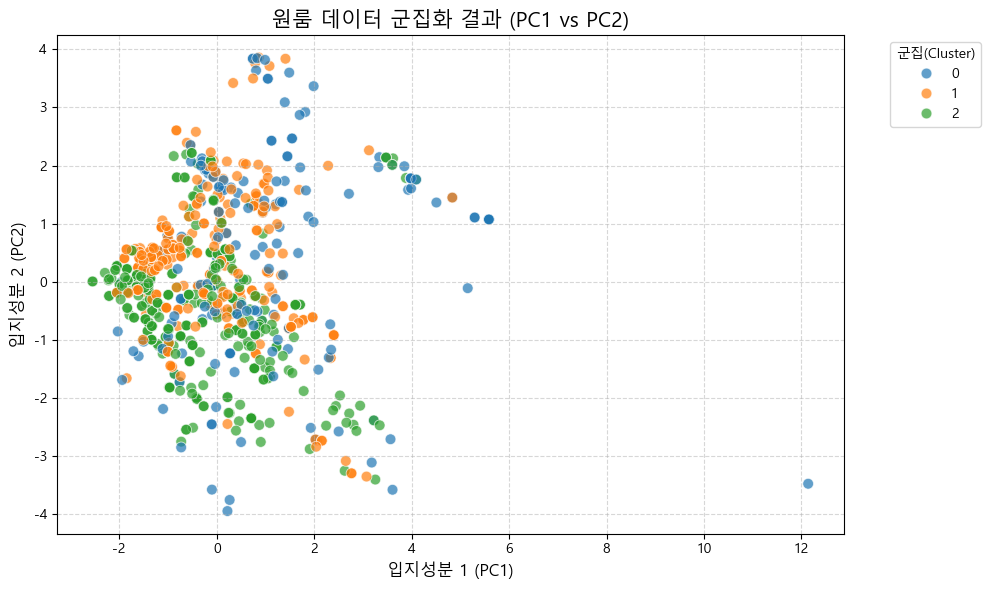

📊 [군집별 주요 변수 평균값]
            월세     보증금   전용면적   노후도
cluster                            
0        30.33  169.88  32.55  7.23
1        34.01  176.80  28.75  6.26
2        31.58  136.89  27.18  8.08


In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. K-Means 군집화 (K=4로 설정)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 2. 산점도 시각화 (PC1, PC2 기준)
plt.figure(figsize=(10, 6))

# 한글 폰트 설정 (환경에 따라 'Malgun Gothic' 또는 'AppleGothic')
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

sns.scatterplot(
    data=df, 
    x='PC1', 
    y='PC2', 
    hue='cluster', 
    palette='tab10', 
    alpha=0.7, 
    s=60
)

plt.title('원룸 데이터 군집화 결과 (PC1 vs PC2)', fontsize=15)
plt.xlabel('입지성분 1 (PC1)', fontsize=12)
plt.ylabel('입지성분 2 (PC2)', fontsize=12)
plt.legend(title='군집(Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# 3. 군집별 특징 요약 확인
print("📊 [군집별 주요 변수 평균값]")
print(df.groupby('cluster')[['월세', '보증금', '전용면적', '노후도']].mean().round(2))

In [ ]:
# 분석에 핵심적인 변수들만 골라서 그립니다 (너무 많으면 느려져요)
target_cols = ['보증금', '전용면적', '노후도', '해당층', '엘리베이터', 
    'PC1', 'PC2', 'PC3', '풀옵션', '남향','cluster']

sns.pairplot(
    df[target_cols], 
    hue='cluster', 
    palette='tab10',
    diag_kind='kde' # 대각선에는 분포 곡선을 그림
)
plt.show()

In [5]:
# 1. 먼저 원핫 인코딩 수행
df_encoded = pd.get_dummies(df, columns=['cluster'], prefix='cluster')

# 2. 인코딩된 결과를 다시 df에 할당
df = df_encoded

# 3. 이제 df에서 모든 bool 타입을 찾아서 int로 변환 (원핫 인코딩으로 생긴 컬럼들까지 포함됨)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# 4. 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 843 entries, 0 to 981
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   보증금             843 non-null    int64  
 1   월세              843 non-null    float64
 2   전용면적            843 non-null    float64
 3   노후도             843 non-null    float64
 4   해당층             843 non-null    int64  
 5   전체층             843 non-null    int64  
 6   엘리베이터           843 non-null    int64  
 7   위도              843 non-null    float64
 8   경도              843 non-null    float64
 9   지하철역_거리(m)      843 non-null    float64
 10  세탁소_거리(m)       843 non-null    float64
 11  카페_거리(m)        843 non-null    float64
 12  약국_거리(m)        843 non-null    float64
 13  대형마트_거리(m)      843 non-null    float64
 14  편의점_거리(m)       843 non-null    float64
 15  버스정류장_거리(m)     843 non-null    float64
 16  남향              843 non-null    int64  
 17  풀옵션             843 non-null    int64  


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 원핫 인코딩 (Cluster 변수를 펼쳐서 모델이 오해하지 않게 함)

# 2. 학습 변수(X)와 정답(y) 설정
# 사용자가 선택한 모든 변수 + 원핫 인코딩된 클러스터 변수들
features = ['보증금', '전용면적', '노후도', '해당층', '전체층', '엘리베이터', '남향', '풀옵션', 'PC1', 'PC2', 'cluster_0', 'cluster_1', 'cluster_2']
cluster_cols = [col for col in df.columns if col.startswith('cluster_')]
final_features = features + cluster_cols

X = df[final_features]
y = df['월세']

# 3. 학습/테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 앙상블 모델(Voting) 학습
# 3가지 강력한 모델을 결합하여 예측력과 안정성을 극대화합니다.
rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, random_state=42)

voting_model = VotingRegressor(estimators=[('rf', rf), ('gb', gb), ('hgb', hgb)])
voting_model.fit(X_train, y_train)

# 5. 결과 확인
y_pred = voting_model.predict(X_test)
print(f"📈 최종 모델 R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"📉 최종 모델 MAE (평균 오차): {mean_absolute_error(y_test, y_pred):.2f}만원")

📈 최종 모델 R2 Score: 0.7014
📉 최종 모델 MAE (평균 오차): 2.36만원
